# TP0 : Modèles interprétables et explications en apprentissage automatique
## Pr S. MHAMMEDI (XAI) 2025-2026

### Objectifs
1. Comprendre les modèles intrinsèquement interprétables : régression linéaire, OLS, régression logistique, arbres de décision.
2. Visualiser et expliquer les effets des variables (globaux et locaux).
3. Expérimenter avec des modèles basés sur les exemples (KNN) et comprendre la prédiction pour une instance individuelle.

## Partie 0 : Installation et import des packages nécessaires

In [25]:
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import statsmodels.api as sm
from sklearn.datasets import load_breast_cancer
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier, KNeighborsRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier, plot_tree

warnings.filterwarnings("ignore")

plt.style.use("seaborn-v0_8-darkgrid")
sns.set_palette("husl")

print("Packages importés avec succès!")

Packages importés avec succès!


## Partie 1 : Régression linéaire
### Prédiction du prix des maisons

In [26]:
# Charger le dataset House Sales
url = "https://szymon.bobek.re/kc_house_data.csv"

df_house = pd.read_csv(url)
print("Dataset chargé!")
print(f"Dimensions: {df_house.shape}")
print("\nPremières lignes:")
df_house.head()

Dataset chargé!
Dimensions: (21613, 21)

Premières lignes:


,id,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,...,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
0,7129300520,20141013T000000,221900.0,3,1.00,1180,5650,1.0,0,0,...,7,1180,0,1955,0,98178,47.5112,-122.257,1340,5650
1,6414100192,20141209T000000,538000.0,3,2.25,2570,7242,2.0,0,0,...,7,2170,400,1951,1991,98125,47.7210,-122.319,1690,7639
2,5631500400,20150225T000000,180000.0,2,1.00,770,10000,1.0,0,0,...,6,770,0,1933,0,98028,47.7379,-122.233,2720,8062
3,2487200875,20141209T000000,604000.0,4,3.00,1960,5000,1.0,0,0,...,7,1050,910,1965,0,98136,47.5208,-122.393,1360,5000
4,1954400510,20150218T000000,510000.0,3,2.00,1680,8080,1.0,0,0,...,8,1680,0,1987,0,98074,47.6168,-122.045,1800,7503


In [27]:
# Sélection des variables pertinentes
features = [
    "bedrooms",
    "bathrooms",
    "sqft_living",
    "sqft_lot",
    "floors",
    "waterfront",
    "view",
    "condition",
    "grade",
    "sqft_above",
]
X = df_house[features]
y = df_house["price"]

# Division train/test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Taille de l'ensemble d'entraînement: {X_train.shape}")
print(f"Taille de l'ensemble de test: {X_test.shape}")

Taille de l'ensemble d'entraînement: (17290, 10)
Taille de l'ensemble de test: (4323, 10)


In [28]:
# Modèle 1: LinearRegression de scikit-learn
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)

# Modèle 2: OLS de statsmodels (avec constante)
X_train_const = sm.add_constant(X_train)
ols_model = sm.OLS(y_train, X_train_const).fit()

print("Modèles entraînés avec succès!")
print(f"\nScore R² (LinearRegression): {lr_model.score(X_train, y_train):.4f}")
print(f"Score R² (OLS): {ols_model.rsquared:.4f}")

Modèles entraînés avec succès!

Score R² (LinearRegression): 0.6025
Score R² (OLS): 0.6025


### Question 1: Afficher les coefficients du modèle LinearRegression

In [29]:
# Coefficients de LinearRegression
coef_lr = pd.DataFrame({"Variable": features, "Coefficient (LinearRegression)": lr_model.coef_})
coef_lr = coef_lr.sort_values("Coefficient (LinearRegression)", ascending=False)
print("\n--- Coefficients LinearRegression ---")
print(coef_lr)

# Coefficients de OLS
print("\n--- Coefficients OLS ---")
print(ols_model.params)


--- Coefficients LinearRegression ---
      Variable  Coefficient (LinearRegression)
5   waterfront                   563700.597755
8        grade                   101139.682745
6         view                    61588.247375
7    condition                    51022.243908
2  sqft_living                      217.262937
3     sqft_lot                       -0.336637
9   sqft_above                      -30.258361
4       floors                    -3197.703917
1    bathrooms                   -12285.409200
0     bedrooms                   -32394.617100

--- Coefficients OLS ---
const         -680282.357946
bedrooms       -32394.617100
bathrooms      -12285.409200
sqft_living       217.262937
sqft_lot           -0.336637
floors          -3197.703917
waterfront     563700.597755
view            61588.247375
condition       51022.243908
grade          101139.682745
sqft_above        -30.258361
dtype: float64


### Question 2: Vérifier les erreurs standards des coefficients pour le modèle OLS

In [30]:
# Résumé complet du modèle OLS
print(ols_model.summary())

print("\n--- Erreurs standards ---")
print(ols_model.bse)

                            OLS Regression Results                            
Dep. Variable:                  price   R-squared:                       0.603
Model:                            OLS   Adj. R-squared:                  0.602
Method:                 Least Squares   F-statistic:                     2619.
Date:                Wed, 17 Dec 2025   Prob (F-statistic):               0.00
Time:                        19:43:16   Log-Likelihood:            -2.3783e+05
No. Observations:               17290   AIC:                         4.757e+05
Df Residuals:                   17279   BIC:                         4.758e+05
Df Model:                          10                                         
Covariance Type:            nonrobust                                         
                  coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------
const       -6.803e+05   1.92e+04    -35.408      

### Question 3: Comparer les coefficients des deux modèles

In [31]:
comparison = pd.DataFrame(
    {
        "Variable": ["const"] + features,
        "OLS": ols_model.params.values,
        "LinearRegression": [lr_model.intercept_] + list(lr_model.coef_),
    }
)
comparison["Différence"] = comparison["OLS"] - comparison["LinearRegression"]
print(comparison)

print("\n--- Réponse ---")
print("Les coefficients sont identiques pour les deux modèles.")
print("OLS et LinearRegression utilisent tous deux la méthode des moindres carrés ordinaires.")
print("La seule différence est que statsmodels fournit plus de statistiques (p-values, intervalles de confiance, etc.)")

       Variable            OLS  LinearRegression    Différence
0         const -680282.357946    -680282.357946 -1.766020e-07
1      bedrooms  -32394.617100     -32394.617100  1.058652e-09
2     bathrooms  -12285.409200     -12285.409200 -3.031346e-08
3   sqft_living     217.262937        217.262937  2.290790e-11
4      sqft_lot      -0.336637         -0.336637  1.365535e-11
5        floors   -3197.703917      -3197.703917  1.932676e-10
6    waterfront  563700.597755     563700.597755 -3.492460e-10
7          view   61588.247375      61588.247375  1.018634e-10
8     condition   51022.243908      51022.243908  1.018634e-10
9         grade  101139.682745     101139.682745 -3.201421e-10
10   sqft_above     -30.258361        -30.258361 -6.295409e-12

--- Réponse ---
Les coefficients sont identiques pour les deux modèles.
OLS et LinearRegression utilisent tous deux la méthode des moindres carrés ordinaires.
La seule différence est que statsmodels fournit plus de statistiques (p-values, inte

### Question 4: Tracer un graphique d'effet (effect plot) pour toutes les variables

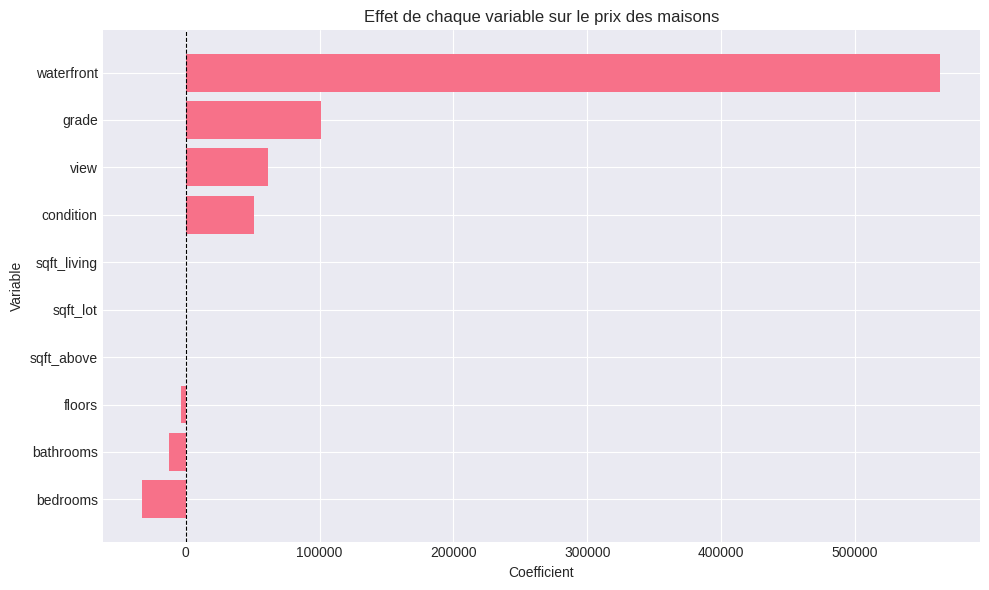


--- Commentaires ---
sqft_living: Effet positif très important - chaque pied carré supplémentaire augmente le prix
grade: Effet positif important - une meilleure note augmente significativement le prix
waterfront: Effet positif - les maisons au bord de l'eau sont plus chères
view: Effet positif - une meilleure vue augmente le prix
sqft_above: Peut avoir un effet négatif si corrélé avec sqft_living
bedrooms: Peut avoir un effet négatif (effet de collinéarité avec sqft_living)


In [32]:
# Graphique des coefficients
coef_sorted = coef_lr.sort_values("Coefficient (LinearRegression)")

plt.figure(figsize=(10, 6))
plt.barh(coef_sorted["Variable"], coef_sorted["Coefficient (LinearRegression)"])
plt.xlabel("Coefficient")
plt.ylabel("Variable")
plt.title("Effet de chaque variable sur le prix des maisons")
plt.axvline(x=0, color="black", linestyle="--", linewidth=0.8)
plt.tight_layout()
plt.show()

print("\n--- Commentaires ---")
print("sqft_living: Effet positif très important - chaque pied carré supplémentaire augmente le prix")
print("grade: Effet positif important - une meilleure note augmente significativement le prix")
print("waterfront: Effet positif - les maisons au bord de l'eau sont plus chères")
print("view: Effet positif - une meilleure vue augmente le prix")
print("sqft_above: Peut avoir un effet négatif si corrélé avec sqft_living")
print("bedrooms: Peut avoir un effet négatif (effet de collinéarité avec sqft_living)")

### Question 5: Créer une fonction permettant de visualiser l'effet pour une maison spécifique


=== Analyse pour la maison #526 ===


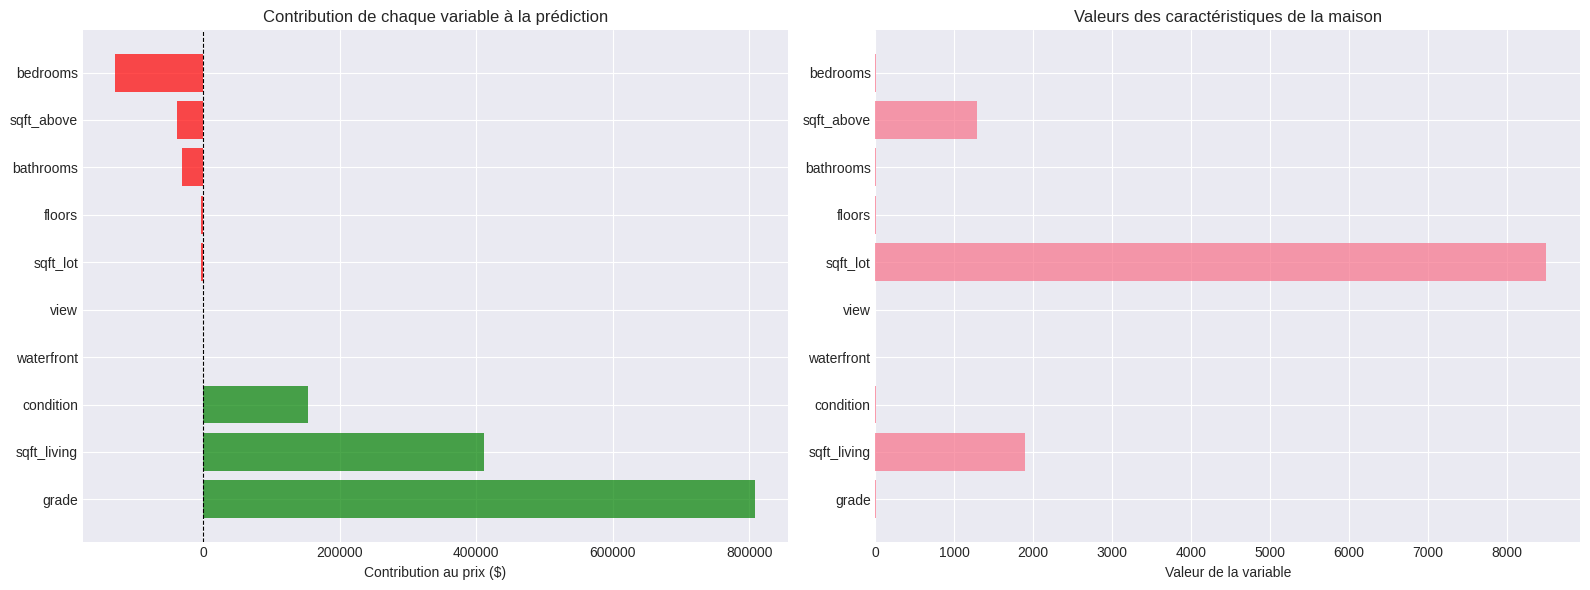


--- Détails de la prédiction ---
Intercept: $-680,282.36
Somme des contributions: $1,167,425.07
Prix prédit: $487,142.71
Prix réel: $437,000.00
Erreur: $50,142.71 (11.47%)

       Variable  Valeur    Coefficient   Contribution
8        grade     8.0  101139.682745  809117.461961
2  sqft_living  1890.0     217.262937  410626.950065
7    condition     3.0   51022.243908  153066.731725
5   waterfront     0.0  563700.597755       0.000000
6         view     0.0   61588.247375       0.000000
3     sqft_lot  8505.0      -0.336637   -2863.095018
4       floors     1.0   -3197.703917   -3197.703917
1    bathrooms     2.5  -12285.409200  -30713.523000
9   sqft_above  1290.0     -30.258361  -39033.285091
0     bedrooms     4.0  -32394.617100 -129578.468401


In [33]:
def effect_plot_instance(model, instance, feature_names, prix_reel=None):
    """
    Visualise l'effet de chaque variable pour une instance spécifique.

    Parameters:
    - model: modèle de régression linéaire entraîné
    - instance: array des valeurs de l'instance
    - feature_names: liste des noms de variables
    - prix_reel: prix réel de la maison (optionnel)
    """
    contributions = model.coef_ * instance
    prediction = model.predict([instance])[0]

    contrib_df = pd.DataFrame(
        {"Variable": feature_names, "Valeur": instance, "Coefficient": model.coef_, "Contribution": contributions}
    )
    contrib_df = contrib_df.sort_values("Contribution", ascending=False)

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

    # Graphique 1: Contributions
    colors = ["green" if x > 0 else "red" for x in contrib_df["Contribution"]]
    ax1.barh(contrib_df["Variable"], contrib_df["Contribution"], color=colors, alpha=0.7)
    ax1.set_xlabel("Contribution au prix ($)")
    ax1.set_title("Contribution de chaque variable à la prédiction")
    ax1.axvline(x=0, color="black", linestyle="--", linewidth=0.8)

    # Graphique 2: Valeurs de l'instance
    ax2.barh(contrib_df["Variable"], contrib_df["Valeur"], alpha=0.7)
    ax2.set_xlabel("Valeur de la variable")
    ax2.set_title("Valeurs des caractéristiques de la maison")

    plt.tight_layout()
    plt.show()

    print("\n--- Détails de la prédiction ---")
    print(f"Intercept: ${model.intercept_:,.2f}")
    print(f"Somme des contributions: ${contributions.sum():,.2f}")
    print(f"Prix prédit: ${prediction:,.2f}")
    if prix_reel is not None:
        print(f"Prix réel: ${prix_reel:,.2f}")
        print(f"Erreur: ${prediction - prix_reel:,.2f} ({((prediction - prix_reel) / prix_reel) * 100:.2f}%)")

    return contrib_df


# Test de la fonction avec une maison aléatoire
idx_test = np.random.randint(0, len(X_test))
instance_test = X_test.iloc[idx_test].values
prix_reel_test = y_test.iloc[idx_test]

print(f"\n=== Analyse pour la maison #{idx_test} ===")
contrib_table = effect_plot_instance(lr_model, instance_test, features, prix_reel_test)
print("\n", contrib_table)

## Partie 2 : K-nearest neighbors (KNN)
### Prédiction du prix avec les maisons similaires

In [34]:
# Normalisation des données
scaler_X = StandardScaler()
scaler_y = StandardScaler()

X_train_scaled = scaler_X.fit_transform(X_train)
X_test_scaled = scaler_X.transform(X_test)
y_train_scaled = scaler_y.fit_transform(y_train.values.reshape(-1, 1)).ravel()
y_test_scaled = scaler_y.transform(y_test.values.reshape(-1, 1)).ravel()

# Construction du modèle KNN
knn_model = KNeighborsRegressor(n_neighbors=5)
knn_model.fit(X_train_scaled, y_train_scaled)

print("Modèle KNN entraîné avec succès!")
print(f"Score R² (KNN sur données normalisées): {knn_model.score(X_test_scaled, y_test_scaled):.4f}")

Modèle KNN entraîné avec succès!
Score R² (KNN sur données normalisées): 0.6403


### Question 1: Prédire le prix pour une maison choisie au hasard

In [35]:
# Choisir une maison aléatoire
idx_knn = np.random.randint(0, len(X_test))
instance_knn = X_test.iloc[idx_knn : idx_knn + 1]
instance_knn_scaled = X_test_scaled[idx_knn : idx_knn + 1]
prix_reel_knn = y_test.iloc[idx_knn]

# Prédiction
pred_scaled = knn_model.predict(instance_knn_scaled)[0]
pred_real = scaler_y.inverse_transform([[pred_scaled]])[0][0]

print(f"\n=== Prédiction KNN pour la maison #{idx_knn} ===")
print("Caractéristiques de la maison:")
print(instance_knn.T)
print(f"\nPrix prédit (normalisé): {pred_scaled:.4f}")
print(f"Prix prédit (réel): ${pred_real:,.2f}")
print(f"Prix réel: ${prix_reel_knn:,.2f}")
print(f"Erreur: ${pred_real - prix_reel_knn:,.2f}")


=== Prédiction KNN pour la maison #1896 ===
Caractéristiques de la maison:
               4574
bedrooms        2.0
bathrooms       1.0
sqft_living   960.0
sqft_lot     4400.0
floors          1.0
waterfront      0.0
view            0.0
condition       4.0
grade           7.0
sqft_above    960.0

Prix prédit (normalisé): 0.0183
Prix prédit (réel): $544,400.00
Prix réel: $319,000.00
Erreur: $225,400.00


### Question 2: Identifier les maisons voisines

In [36]:
# Trouver les voisins
distances, indices = knn_model.kneighbors(instance_knn_scaled)

print(f"\n=== Les {knn_model.n_neighbors} voisins les plus proches ===")
print(f"\nIndices des voisins: {indices[0]}")
print(f"Distances: {distances[0]}")

# Récupérer les prix des voisins
neighbor_prices = y_train.iloc[indices[0]].values
neighbor_prices_scaled = y_train_scaled[indices[0]]

neighbors_df = pd.DataFrame(
    {
        "Voisin": range(1, len(indices[0]) + 1),
        "Distance": distances[0],
        "Prix (normalisé)": neighbor_prices_scaled,
        "Prix (réel)": neighbor_prices,
    }
)

print("\n", neighbors_df)
print(f"\nMoyenne des prix des voisins: ${neighbor_prices.mean():,.2f}")
print(f"Prix prédit par KNN: ${pred_real:,.2f}")


=== Les 5 voisins les plus proches ===

Indices des voisins: [ 5474 13946 15294  7110 15350]
Distances: [0.01544874 0.01692923 0.01837154 0.0299963  0.03441775]

    Voisin  Distance  Prix (normalisé)  Prix (réel)
0       1  0.015449         -0.104489     500000.0
1       2  0.016929          0.421166     690000.0
2       3  0.018372          0.033841     550000.0
3       4  0.029996         -0.292619     432000.0
4       5  0.034418          0.033841     550000.0

Moyenne des prix des voisins: $544,400.00
Prix prédit par KNN: $544,400.00


### Question 3: Reconvertir les prix normalisés en prix réels

In [37]:
# Les prix ont déjà été reconvertis dans la question 2
# Voici la formule explicite:

print("Formule de reconversion:")
print("prix_réel = prix_normalisé * std + mean")
print(f"où std = {scaler_y.scale_[0]:.2f} et mean = {scaler_y.mean_[0]:.2f}")
print("\nVérification pour la prédiction:")
print(f"Prix normalisé: {pred_scaled:.4f}")
print(f"Prix reconverti: {pred_scaled * scaler_y.scale_[0] + scaler_y.mean_[0]:,.2f}")
print(f"Prix prédit (méthode inverse_transform): ${pred_real:,.2f}")

Formule de reconversion:
prix_réel = prix_normalisé * std + mean
où std = 361453.47 et mean = 537768.05

Vérification pour la prédiction:
Prix normalisé: 0.0183
Prix reconverti: 544,400.00
Prix prédit (méthode inverse_transform): $544,400.00


### Question 4: Comparer l'explication KNN avec celle de la régression linéaire


=== Comparaison KNN vs Régression Linéaire ===
Prix réel: $319,000.00
Prix prédit (KNN): $544,400.00
Prix prédit (Régression Linéaire): $329,555.24

Erreur KNN: $225,400.00
Erreur Régression Linéaire: $10,555.24


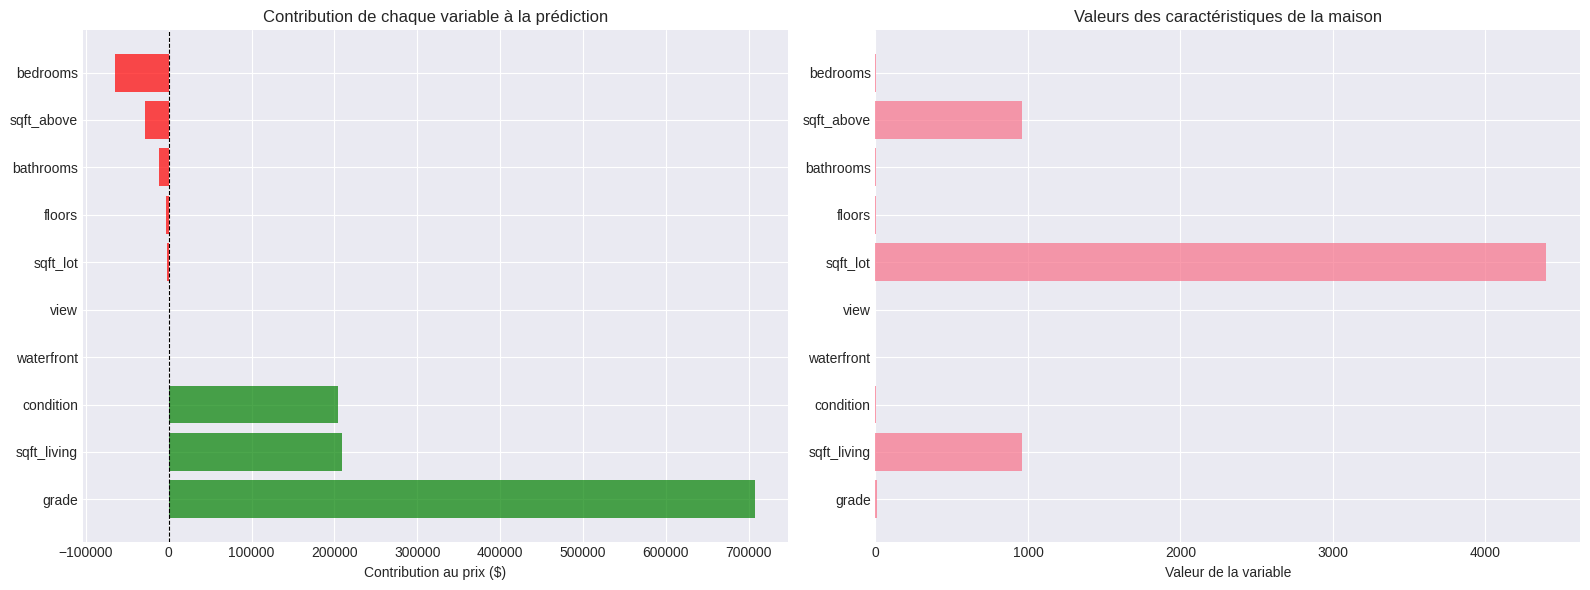


--- Détails de la prédiction ---
Intercept: $-680,282.36
Somme des contributions: $1,009,837.60
Prix prédit: $329,555.24
Prix réel: $319,000.00
Erreur: $10,555.24 (3.31%)

--- Différences observées ---
1. KNN: La prédiction est basée sur la moyenne des 5 maisons les plus similaires
   - Explication locale basée sur des exemples concrets
   - Plus flexible, peut capturer des relations non-linéaires

2. Régression Linéaire: La prédiction est basée sur une combinaison linéaire des variables
   - Explication globale via les coefficients
   - Relation linéaire fixe entre variables et prix
   - Plus facile à interpréter (effet de chaque variable)

3. KNN fournit des exemples concrets (voisins) tandis que LR fournit des règles générales


In [38]:
# Prédiction de la régression linéaire pour la même maison
pred_lr = lr_model.predict(instance_knn)[0]

print("\n=== Comparaison KNN vs Régression Linéaire ===")
print(f"Prix réel: ${prix_reel_knn:,.2f}")
print(f"Prix prédit (KNN): ${pred_real:,.2f}")
print(f"Prix prédit (Régression Linéaire): ${pred_lr:,.2f}")
print(f"\nErreur KNN: ${abs(pred_real - prix_reel_knn):,.2f}")
print(f"Erreur Régression Linéaire: ${abs(pred_lr - prix_reel_knn):,.2f}")

# Visualisation des contributions de la régression linéaire
contrib_lr = effect_plot_instance(lr_model, instance_knn.values[0], features, prix_reel_knn)

print("\n--- Différences observées ---")
print("1. KNN: La prédiction est basée sur la moyenne des 5 maisons les plus similaires")
print("   - Explication locale basée sur des exemples concrets")
print("   - Plus flexible, peut capturer des relations non-linéaires")
print("\n2. Régression Linéaire: La prédiction est basée sur une combinaison linéaire des variables")
print("   - Explication globale via les coefficients")
print("   - Relation linéaire fixe entre variables et prix")
print("   - Plus facile à interpréter (effet de chaque variable)")
print("\n3. KNN fournit des exemples concrets (voisins) tandis que LR fournit des règles générales")

## Partie 3 : Régression logistique
### Classification du cancer du sein

In [39]:
# Charger le dataset cancer du sein
cancer = load_breast_cancer()
X_cancer = pd.DataFrame(cancer.data, columns=cancer.feature_names)
y_cancer = cancer.target

print("Dataset cancer du sein chargé!")
print(f"Dimensions: {X_cancer.shape}")
print(f"Classes: {cancer.target_names}")
print("\nDistribution des classes:")
print(pd.Series(y_cancer).value_counts())
print("\nPremières variables:")
print(X_cancer.columns[:10].tolist())

Dataset cancer du sein chargé!
Dimensions: (569, 30)
Classes: ['malignant' 'benign']

Distribution des classes:
1    357
0    212
Name: count, dtype: int64

Premières variables:
['mean radius', 'mean texture', 'mean perimeter', 'mean area', 'mean smoothness', 'mean compactness', 'mean concavity', 'mean concave points', 'mean symmetry', 'mean fractal dimension']


In [40]:
# Division train/test
X_train_cancer, X_test_cancer, y_train_cancer, y_test_cancer = train_test_split(
    X_cancer, y_cancer, test_size=0.2, random_state=42
)

# Normalisation
scaler_cancer = StandardScaler()
X_train_cancer_scaled = scaler_cancer.fit_transform(X_train_cancer)
X_test_cancer_scaled = scaler_cancer.transform(X_test_cancer)

# Entraînement du modèle
log_model = LogisticRegression(max_iter=10000, random_state=42)
log_model.fit(X_train_cancer_scaled, y_train_cancer)

print("Modèle de régression logistique entraîné!")
print(f"Précision (train): {log_model.score(X_train_cancer_scaled, y_train_cancer):.4f}")
print(f"Précision (test): {log_model.score(X_test_cancer_scaled, y_test_cancer):.4f}")

Modèle de régression logistique entraîné!
Précision (train): 0.9868
Précision (test): 0.9737


### Visualisation de l'importance des variables

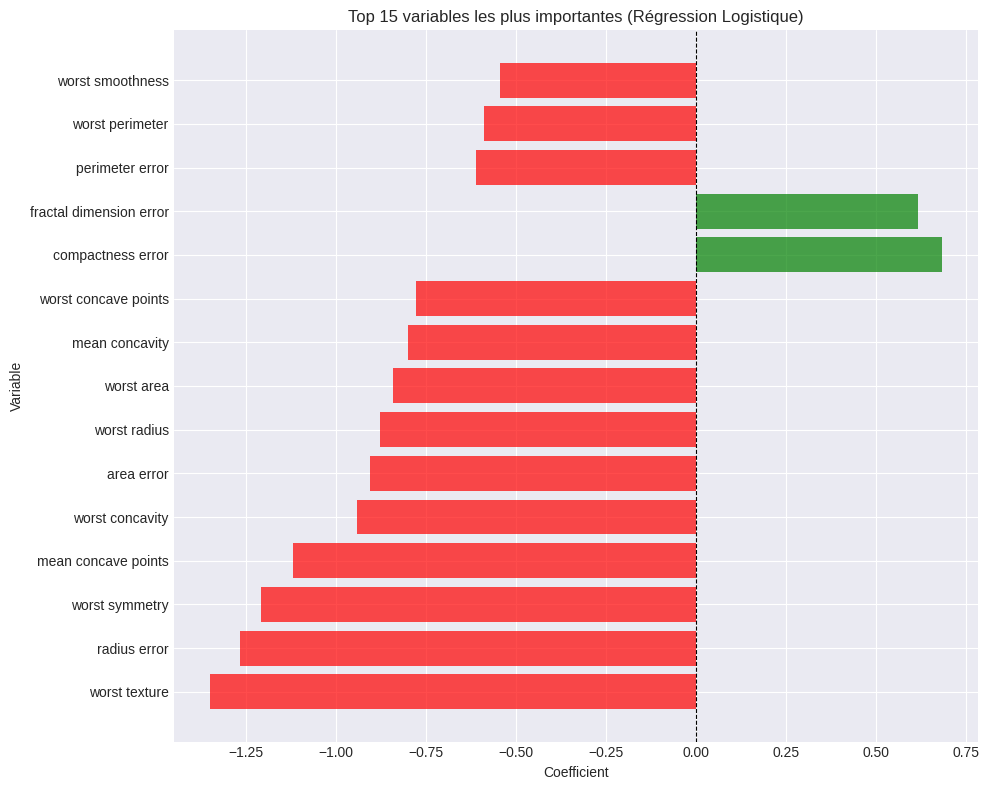


Top 10 variables:
                Variable  Coefficient
21         worst texture    -1.350606
10          radius error    -1.268178
28        worst symmetry    -1.208200
7    mean concave points    -1.119804
26       worst concavity    -0.943053
13            area error    -0.907186
20          worst radius    -0.879840
23            worst area    -0.841846
6         mean concavity    -0.801458
27  worst concave points    -0.778217


In [41]:
# Coefficients du modèle logistique
coef_log = pd.DataFrame({"Variable": X_cancer.columns, "Coefficient": log_model.coef_[0]})
coef_log["Abs_Coefficient"] = np.abs(coef_log["Coefficient"])
coef_log = coef_log.sort_values("Coefficient", ascending=False)

# Top 15 variables
top_15 = coef_log.nlargest(15, "Abs_Coefficient")

plt.figure(figsize=(10, 8))
colors = ["green" if x > 0 else "red" for x in top_15["Coefficient"]]
plt.barh(top_15["Variable"], top_15["Coefficient"], color=colors, alpha=0.7)
plt.xlabel("Coefficient")
plt.ylabel("Variable")
plt.title("Top 15 variables les plus importantes (Régression Logistique)")
plt.axvline(x=0, color="black", linestyle="--", linewidth=0.8)
plt.tight_layout()
plt.show()

print("\nTop 10 variables:")
print(coef_log.nlargest(10, "Abs_Coefficient")[["Variable", "Coefficient"]])

### Question 1: Quelles sont les variables les plus importantes pour la prédiction ?

In [42]:
print("=== Variables les plus importantes ===")
print("\nBasé sur la valeur absolue des coefficients:")
top_10_importance = coef_log.nlargest(10, "Abs_Coefficient")[["Variable", "Coefficient", "Abs_Coefficient"]]
print(top_10_importance)

print("\n--- Réponse ---")
print("Les variables les plus importantes sont celles avec les coefficients absolus les plus élevés.")
print("Elles ont le plus grand impact sur la probabilité de classification.")
print("Exemples: worst perimeter, worst concave points, mean concave points, etc.")

=== Variables les plus importantes ===

Basé sur la valeur absolue des coefficients:
                Variable  Coefficient  Abs_Coefficient
21         worst texture    -1.350606         1.350606
10          radius error    -1.268178         1.268178
28        worst symmetry    -1.208200         1.208200
7    mean concave points    -1.119804         1.119804
26       worst concavity    -0.943053         0.943053
13            area error    -0.907186         0.907186
20          worst radius    -0.879840         0.879840
23            worst area    -0.841846         0.841846
6         mean concavity    -0.801458         0.801458
27  worst concave points    -0.778217         0.778217

--- Réponse ---
Les variables les plus importantes sont celles avec les coefficients absolus les plus élevés.
Elles ont le plus grand impact sur la probabilité de classification.
Exemples: worst perimeter, worst concave points, mean concave points, etc.


### Question 2: Comment interpréter le signe (positif/négatif) des coefficients ?

In [43]:
print("=== Interprétation des signes des coefficients ===")
print(f"\nClasses: 0 = {cancer.target_names[0]}, 1 = {cancer.target_names[1]}")

pos_coef = coef_log[coef_log["Coefficient"] > 0].nlargest(5, "Coefficient")
neg_coef = coef_log[coef_log["Coefficient"] < 0].nsmallest(5, "Coefficient")

print("\nTop 5 coefficients POSITIFS (favorisent la classe BENIGN = 1):")
print(pos_coef[["Variable", "Coefficient"]])

print("\nTop 5 coefficients NÉGATIFS (favorisent la classe MALIGNANT = 0):")
print(neg_coef[["Variable", "Coefficient"]])

print("\n--- Réponse ---")
print("• Coefficient POSITIF: Augmente la probabilité de classe 1 (BENIGN - bénigne)")
print("  - Une valeur élevée de cette variable indique une tumeur bénigne")
print("\n• Coefficient NÉGATIF: Augmente la probabilité de classe 0 (MALIGNANT - maligne)")
print("  - Une valeur élevée de cette variable indique une tumeur maligne")
print('\nExemple: Si "worst concave points" a un coefficient négatif,')
print("         cela signifie que plus cette valeur est élevée, plus la tumeur est susceptible d'être maligne.")

=== Interprétation des signes des coefficients ===

Classes: 0 = malignant, 1 = benign

Top 5 coefficients POSITIFS (favorisent la classe BENIGN = 1):
                   Variable  Coefficient
15        compactness error     0.682491
19  fractal dimension error     0.616230
5          mean compactness     0.540164
18           symmetry error     0.500425
8             mean symmetry     0.236119

Top 5 coefficients NÉGATIFS (favorisent la classe MALIGNANT = 0):
               Variable  Coefficient
21        worst texture    -1.350606
10         radius error    -1.268178
28       worst symmetry    -1.208200
7   mean concave points    -1.119804
26      worst concavity    -0.943053

--- Réponse ---
• Coefficient POSITIF: Augmente la probabilité de classe 1 (BENIGN - bénigne)
  - Une valeur élevée de cette variable indique une tumeur bénigne

• Coefficient NÉGATIF: Augmente la probabilité de classe 0 (MALIGNANT - maligne)
  - Une valeur élevée de cette variable indique une tumeur maligne

Ex

## Partie 4 : Arbres de décision
### Modèle avec le dataset cancer

Arbre de décision entraîné!
Précision (train): 0.9780
Précision (test): 0.9474


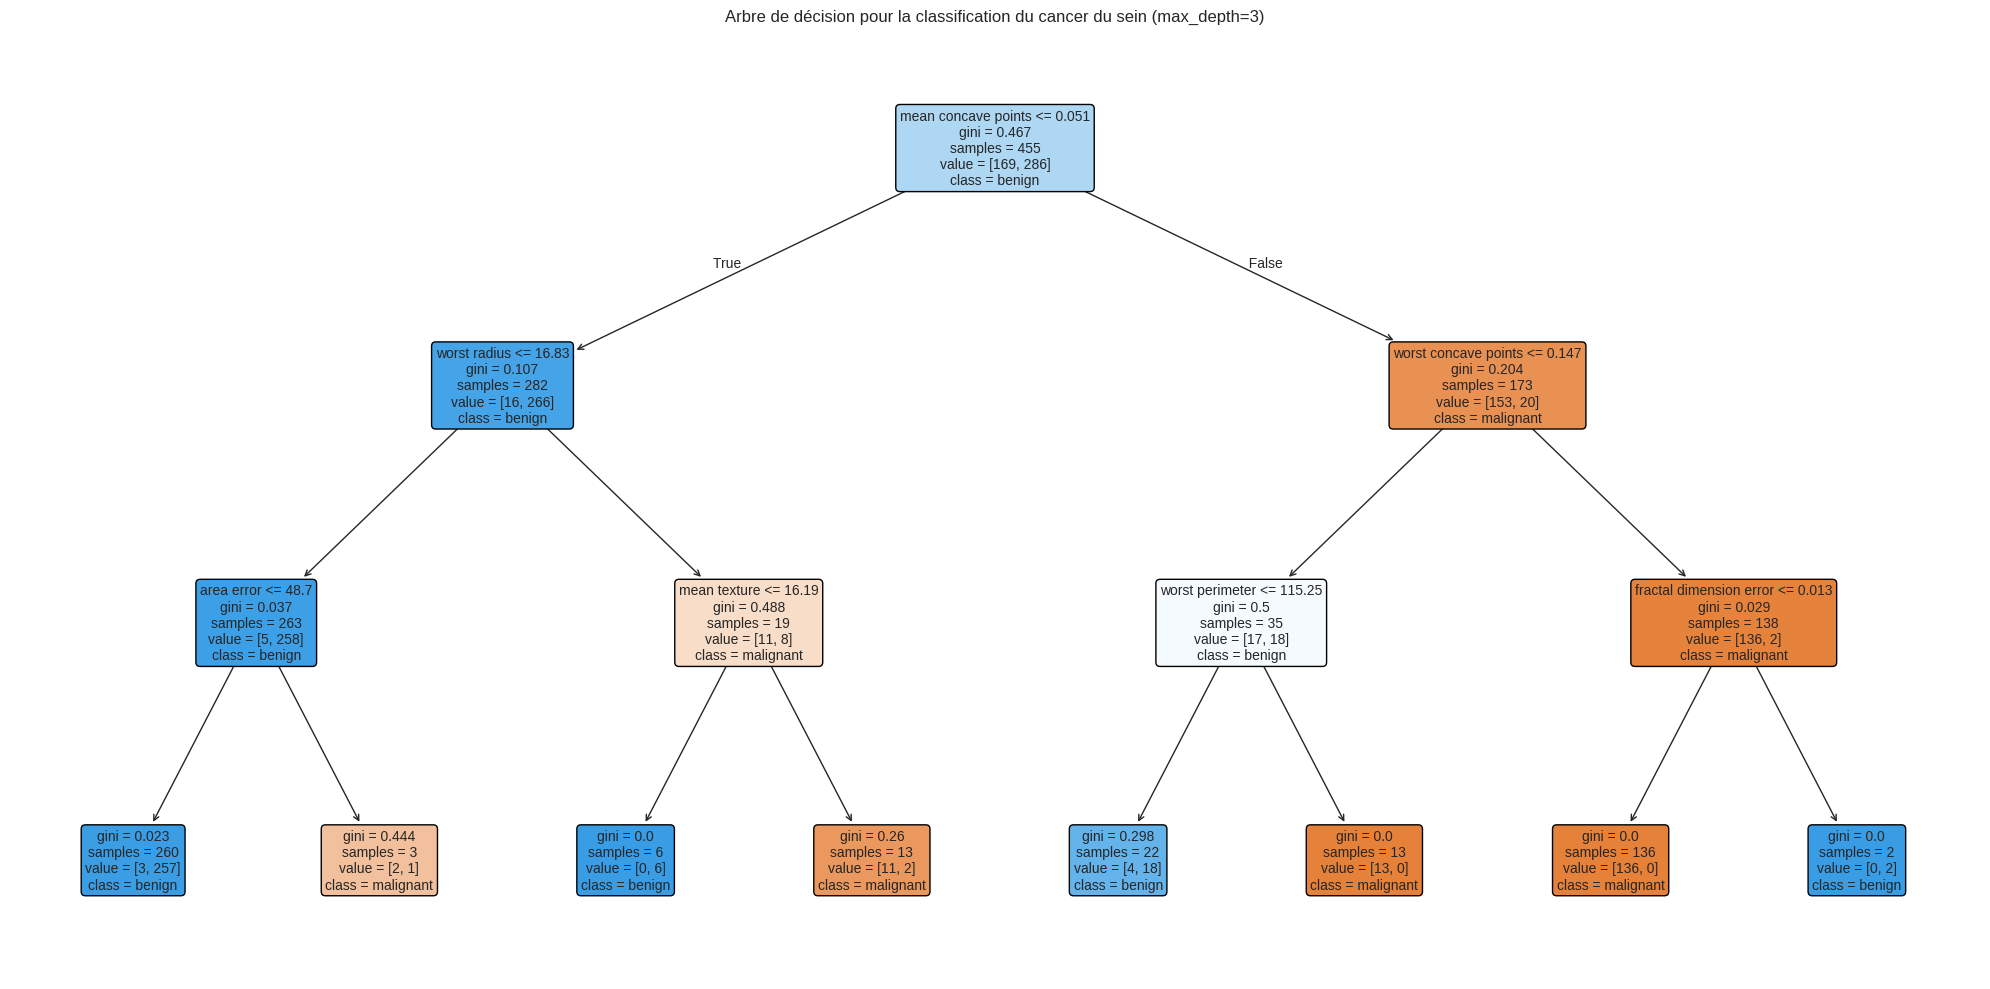

In [44]:
# Construction d'un arbre de décision simple (pour la visualisation)
tree_model = DecisionTreeClassifier(max_depth=3, random_state=42)
tree_model.fit(X_train_cancer, y_train_cancer)

print("Arbre de décision entraîné!")
print(f"Précision (train): {tree_model.score(X_train_cancer, y_train_cancer):.4f}")
print(f"Précision (test): {tree_model.score(X_test_cancer, y_test_cancer):.4f}")

# Visualisation de l'arbre
plt.figure(figsize=(20, 10))
plot_tree(
    tree_model, feature_names=X_cancer.columns, class_names=cancer.target_names, filled=True, fontsize=10, rounded=True
)
plt.title("Arbre de décision pour la classification du cancer du sein (max_depth=3)")
plt.tight_layout()
plt.show()

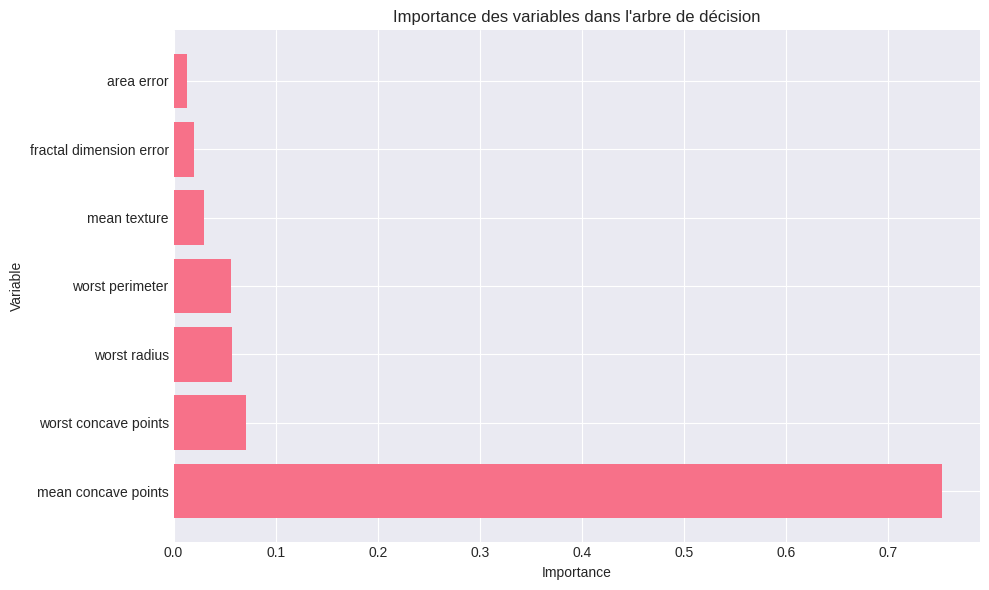


Variables utilisées dans l'arbre:
                   Variable  Importance
7       mean concave points    0.752304
27     worst concave points    0.071432
20             worst radius    0.056905
22          worst perimeter    0.056028
1              mean texture    0.030106
19  fractal dimension error    0.020188
13               area error    0.013038


In [45]:
# Importance des variables dans l'arbre
feature_importance = pd.DataFrame(
    {"Variable": X_cancer.columns, "Importance": tree_model.feature_importances_}
).sort_values("Importance", ascending=False)

top_features = feature_importance[feature_importance["Importance"] > 0]

plt.figure(figsize=(10, 6))
plt.barh(top_features["Variable"], top_features["Importance"])
plt.xlabel("Importance")
plt.ylabel("Variable")
plt.title("Importance des variables dans l'arbre de décision")
plt.tight_layout()
plt.show()

print("\nVariables utilisées dans l'arbre:")
print(top_features)

### Question 1: Peut-on comprendre le comportement global du modèle à partir de l'arbre ?

In [46]:
print("=== Comportement global de l'arbre ===")
print("\n--- Réponse ---")
print("OUI, l'arbre de décision offre une excellente interprétabilité globale:")
print("\n1. VISUALISATION COMPLÈTE:")
print("   - On peut voir toutes les règles de décision")
print("   - Chaque nœud montre la condition de séparation")
print("   - Les feuilles montrent la classe prédite")
print("\n2. RÈGLES EXPLICITES:")
print('   - Par exemple: "Si worst radius <= X alors..."')
print("   - Les chemins de l'arbre représentent des règles IF-THEN")
print("\n3. IMPORTANCE DES VARIABLES:")
print("   - Les variables en haut de l'arbre sont les plus importantes")
print("   - On comprend quelles variables le modèle utilise pour décider")
print("\n4. DISTRIBUTION DES CLASSES:")
print("   - Chaque nœud montre combien d'exemples de chaque classe")
print("   - Permet de comprendre la confiance de la prédiction")

=== Comportement global de l'arbre ===

--- Réponse ---
OUI, l'arbre de décision offre une excellente interprétabilité globale:

1. VISUALISATION COMPLÈTE:
   - On peut voir toutes les règles de décision
   - Chaque nœud montre la condition de séparation
   - Les feuilles montrent la classe prédite

2. RÈGLES EXPLICITES:
   - Par exemple: "Si worst radius <= X alors..."
   - Les chemins de l'arbre représentent des règles IF-THEN

3. IMPORTANCE DES VARIABLES:
   - Les variables en haut de l'arbre sont les plus importantes
   - On comprend quelles variables le modèle utilise pour décider

4. DISTRIBUTION DES CLASSES:
   - Chaque nœud montre combien d'exemples de chaque classe
   - Permet de comprendre la confiance de la prédiction


### Question 2: Peut-on comprendre le comportement local pour une observation spécifique ?

In [47]:
# Prendre une instance de test
idx_tree = 0
instance_tree = X_test_cancer.iloc[idx_tree]
true_class = y_test_cancer[idx_tree]  # CORRIGÉ: utiliser [] au lieu de .iloc[]

# Prédiction
pred_class = tree_model.predict([instance_tree])[0]
pred_proba = tree_model.predict_proba([instance_tree])[0]

# Chemin de décision
decision_path = tree_model.decision_path([instance_tree])
node_indices = decision_path.indices

print(f"=== Explication locale pour l'instance #{idx_tree} ===")
print(f"\nClasse réelle: {cancer.target_names[true_class]}")
print(f"Classe prédite: {cancer.target_names[pred_class]}")
print(f"Probabilités: Malignant={pred_proba[0]:.3f}, Benign={pred_proba[1]:.3f}")

print("\n--- Réponse ---")
print("OUI, l'explication locale est excellente avec les arbres:")
print("\n1. CHEMIN DE DÉCISION:")
print(f"   - L'instance passe par {len(node_indices)} nœuds")
print("   - On peut suivre exactement le chemin dans l'arbre")
print("\n2. RÈGLES APPLIQUÉES:")
print("   - On voit exactement quelles conditions sont vérifiées")
print('   - Par exemple: "worst radius <= 16.795" puis "worst concave points <= 0.136"')
print("\n3. TRANSPARENCE TOTALE:")
print('   - Pas de "boîte noire" - chaque décision est visible')
print("   - On comprend POURQUOI le modèle a fait cette prédiction")

print("\n--- Caractéristiques de l'instance ---")
print(instance_tree[top_features["Variable"][:5]])

=== Explication locale pour l'instance #0 ===

Classe réelle: benign
Classe prédite: benign
Probabilités: Malignant=0.012, Benign=0.988

--- Réponse ---
OUI, l'explication locale est excellente avec les arbres:

1. CHEMIN DE DÉCISION:
   - L'instance passe par 4 nœuds
   - On peut suivre exactement le chemin dans l'arbre

2. RÈGLES APPLIQUÉES:
   - On voit exactement quelles conditions sont vérifiées
   - Par exemple: "worst radius <= 16.795" puis "worst concave points <= 0.136"

3. TRANSPARENCE TOTALE:
   - Pas de "boîte noire" - chaque décision est visible
   - On comprend POURQUOI le modèle a fait cette prédiction

--- Caractéristiques de l'instance ---
mean concave points      0.03821
worst concave points     0.10150
worst radius            14.97000
worst perimeter         96.05000
mean texture            18.60000
Name: 204, dtype: float64


### Question 3: Pour une instance donnée, pouvez-vous dire quelles variables modifier pour changer la décision ?

In [48]:
print("=== Contrefactuels (Counterfactuals) ===")
print("\n--- Réponse ---")
print("OUI, les arbres permettent facilement de trouver des contrefactuels:")
print("\nMÉTHODE:")
print("1. Suivre le chemin de décision de l'instance")
print("2. Identifier les conditions aux nœuds")
print("3. Pour changer la décision, modifier une variable pour inverser une condition")
print("\nEXEMPLE CONCRET:")
print("Si l'instance actuelle:")
print("  - Suit le chemin: worst radius > 16.795 → classe Malignant")
print("  - Pour obtenir Benign, il faut: worst radius <= 16.795")
print("\nPour l'instance actuelle:")

# Trouver les valeurs critiques
if pred_class == 0:  # Malignant
    print("\nClasse actuelle: MALIGNANT")
    print("Pour obtenir BENIGN, on pourrait modifier:")
else:
    print("\nClasse actuelle: BENIGN")
    print("Pour obtenir MALIGNANT, on pourrait modifier:")

# Afficher les valeurs des variables importantes
important_vars = top_features["Variable"][:3].tolist()
print("\nValeurs actuelles des variables clés:")
for var in important_vars:
    print(f"  - {var}: {instance_tree[var]:.3f}")

print("\nCes valeurs correspondent aux seuils visibles dans l'arbre.")
print("En modifiant une valeur au-delà d'un seuil, on change le chemin et donc la prédiction.")

=== Contrefactuels (Counterfactuals) ===

--- Réponse ---
OUI, les arbres permettent facilement de trouver des contrefactuels:

MÉTHODE:
1. Suivre le chemin de décision de l'instance
2. Identifier les conditions aux nœuds
3. Pour changer la décision, modifier une variable pour inverser une condition

EXEMPLE CONCRET:
Si l'instance actuelle:
  - Suit le chemin: worst radius > 16.795 → classe Malignant
  - Pour obtenir Benign, il faut: worst radius <= 16.795

Pour l'instance actuelle:

Classe actuelle: BENIGN
Pour obtenir MALIGNANT, on pourrait modifier:

Valeurs actuelles des variables clés:
  - mean concave points: 0.038
  - worst concave points: 0.102
  - worst radius: 14.970

Ces valeurs correspondent aux seuils visibles dans l'arbre.
En modifiant une valeur au-delà d'un seuil, on change le chemin et donc la prédiction.


### Question 4: Utiliser le modèle KNN pour expliquer les données de classification du cancer

In [50]:
# Construction du modèle KNN pour la classification

knn_cancer = KNeighborsClassifier(n_neighbors=5)
knn_cancer.fit(X_train_cancer_scaled, y_train_cancer)

print("Modèle KNN pour la classification du cancer entraîné!")
print(f"Précision (train): {knn_cancer.score(X_train_cancer_scaled, y_train_cancer):.4f}")
print(f"Précision (test): {knn_cancer.score(X_test_cancer_scaled, y_test_cancer):.4f}")

# Prédiction pour la même instance
instance_cancer_scaled = scaler_cancer.transform([instance_tree])
pred_knn_cancer = knn_cancer.predict(instance_cancer_scaled)[0]
pred_proba_knn = knn_cancer.predict_proba(instance_cancer_scaled)[0]

# Trouver les voisins
distances_cancer, indices_cancer = knn_cancer.kneighbors(instance_cancer_scaled)

print("\n=== Explication KNN pour la même instance ===")
print(f"Classe prédite: {cancer.target_names[pred_knn_cancer]}")
print(f"Probabilités: Malignant={pred_proba_knn[0]:.3f}, Benign={pred_proba_knn[1]:.3f}")

print(f"\n--- Les {knn_cancer.n_neighbors} voisins les plus proches ---")
neighbors_cancer = pd.DataFrame(
    {
        "Voisin": range(1, 6),
        "Distance": distances_cancer[0],
        "Classe": [cancer.target_names[y_train_cancer[i]] for i in indices_cancer[0]],  # ✅ CORRIGÉ
    }
)
print(neighbors_cancer)

# Distribution des classes parmi les voisins
neighbor_classes = [y_train_cancer[i] for i in indices_cancer[0]]  # ✅ CORRIGÉ
class_counts = pd.Series(neighbor_classes).value_counts()
print("\nDistribution des classes parmi les voisins:")
for cls, count in class_counts.items():
    print(f"  {cancer.target_names[cls]}: {count}/{len(neighbor_classes)}")

print("\n--- Explication KNN ---")
print("KNN explique par SIMILARITÉ avec des exemples concrets:")
print("- La prédiction est basée sur le vote majoritaire des 5 voisins")
print("- On peut examiner les cas similaires réels du dataset")
print('- Plus intuitif: "Cette tumeur ressemble à ces 5 autres tumeurs"')
print("- Contrairement à l'arbre qui donne des règles, KNN donne des exemples")

Modèle KNN pour la classification du cancer entraîné!
Précision (train): 0.9802
Précision (test): 0.9474

=== Explication KNN pour la même instance ===
Classe prédite: benign
Probabilités: Malignant=0.000, Benign=1.000

--- Les 5 voisins les plus proches ---
   Voisin  Distance  Classe
0       1  1.558904  benign
1       2  1.676283  benign
2       3  1.740372  benign
3       4  2.058577  benign
4       5  2.077415  benign

Distribution des classes parmi les voisins:
  benign: 5/5

--- Explication KNN ---
KNN explique par SIMILARITÉ avec des exemples concrets:
- La prédiction est basée sur le vote majoritaire des 5 voisins
- On peut examiner les cas similaires réels du dataset
- Plus intuitif: "Cette tumeur ressemble à ces 5 autres tumeurs"
- Contrairement à l'arbre qui donne des règles, KNN donne des exemples


## Partie 5 : Comparaison et synthèse

### Question 1: Quelle est la différence entre effets globaux et effets locaux ?

In [51]:
print("=" * 80)
print("EFFETS GLOBAUX vs EFFETS LOCAUX")
print("=" * 80)

print("\n--- EFFETS GLOBAUX ---")
print("Définition: Expliquent le comportement général du modèle sur l'ensemble du dataset")
print("\nCaractéristiques:")
print("  • Décrivent comment le modèle fonctionne en général")
print("  • Montrent l'importance relative des variables")
print("  • Indépendants d'une instance particulière")
print("\nExemples:")
print("  • Coefficients d'une régression linéaire")
print("  • Importance des variables dans un arbre")
print("  • Graphique d'effet montrant l'impact moyen de chaque variable")
print('\nQuestion répondue: "Comment le modèle fonctionne-t-il en général ?"')

print("\n--- EFFETS LOCAUX ---")
print("Définition: Expliquent la prédiction du modèle pour une instance spécifique")
print("\nCaractéristiques:")
print("  • Spécifiques à une observation donnée")
print("  • Montrent comment les variables affectent cette prédiction particulière")
print("  • Peuvent différer des effets globaux")
print("\nExemples:")
print("  • Contribution de chaque variable à la prédiction d'une maison")
print("  • Chemin de décision dans un arbre pour une instance")
print("  • Voisins utilisés par KNN pour une prédiction")
print('\nQuestion répondue: "Pourquoi le modèle a-t-il fait cette prédiction pour CET exemple ?"')

print("\n--- COMPARAISON ---")
comparison_table = pd.DataFrame(
    {
        "Aspect": ["Portée", "Objectif", "Stabilité", "Usage"],
        "Effets Globaux": [
            "Tout le dataset",
            "Comprendre le modèle",
            "Stable, ne change pas",
            "Validation, compréhension générale",
        ],
        "Effets Locaux": [
            "Une seule instance",
            "Expliquer une prédiction",
            "Varie selon l'instance",
            "Debugging, cas individuels",
        ],
    }
)
print("\n", comparison_table.to_string(index=False))

EFFETS GLOBAUX vs EFFETS LOCAUX

--- EFFETS GLOBAUX ---
Définition: Expliquent le comportement général du modèle sur l'ensemble du dataset

Caractéristiques:
  • Décrivent comment le modèle fonctionne en général
  • Montrent l'importance relative des variables
  • Indépendants d'une instance particulière

Exemples:
  • Coefficients d'une régression linéaire
  • Importance des variables dans un arbre
  • Graphique d'effet montrant l'impact moyen de chaque variable

Question répondue: "Comment le modèle fonctionne-t-il en général ?"

--- EFFETS LOCAUX ---
Définition: Expliquent la prédiction du modèle pour une instance spécifique

Caractéristiques:
  • Spécifiques à une observation donnée
  • Montrent comment les variables affectent cette prédiction particulière
  • Peuvent différer des effets globaux

Exemples:
  • Contribution de chaque variable à la prédiction d'une maison
  • Chemin de décision dans un arbre pour une instance
  • Voisins utilisés par KNN pour une prédiction

Question

### Question 2: Comparez les modèles linéaires, KNN et arbres : avantages et limites pour l'interprétabilité

In [52]:
print("=" * 80)
print("COMPARAISON DES MODÈLES POUR L'INTERPRÉTABILITÉ")
print("=" * 80)

print("\n### 1. MODÈLES LINÉAIRES (Régression Linéaire/Logistique) ###")
print("\nAVANTAGES:")
print("  ✓ Très faciles à interpréter")
print("  ✓ Coefficients = effet direct de chaque variable")
print("  ✓ Explication globale simple: combinaison linéaire")
print("  ✓ Statistiques disponibles (p-values, intervalles de confiance)")
print("  ✓ Rapides à entraîner et à expliquer")
print("  ✓ Prédictions faciles à calculer manuellement")
print("\nLIMITES:")
print("  ✗ Hypothèse de linéarité - ne capture pas les relations complexes")
print("  ✗ Peut mal performer sur des données non-linéaires")
print("  ✗ Sensible à la multicolinéarité")
print("  ✗ Explication locale = explication globale (pas d'adaptation)")

print("\n### 2. K-NEAREST NEIGHBORS (KNN) ###")
print("\nAVANTAGES:")
print("  ✓ Explication par exemples concrets (très intuitif)")
print("  ✓ Pas d'hypothèses sur la forme de la relation")
print("  ✓ Capture les relations non-linéaires")
print('  ✓ Explication locale naturelle: "ressemble à ces cas"')
print("  ✓ Facile à expliquer à des non-experts")
print("\nLIMITES:")
print("  ✗ Pas d'explication globale claire")
print("  ✗ Difficile de comprendre l'importance des variables")
print("  ✗ Sensible au choix de K")
print("  ✗ Nécessite normalisation (impact sur l'interprétabilité)")
print("  ✗ Computationnellement coûteux pour l'explication")
print("  ✗ Difficulté si les voisins sont contradictoires")

print("\n### 3. ARBRES DE DÉCISION ###")
print("\nAVANTAGES:")
print("  ✓ Excellente interprétabilité globale ET locale")
print("  ✓ Règles IF-THEN faciles à comprendre")
print("  ✓ Visualisation intuitive")
print("  ✓ Importance des variables claire")
print("  ✓ Capture les interactions entre variables")
print("  ✓ Pas besoin de normalisation")
print("  ✓ Facile de trouver des contrefactuels")
print("  ✓ Gère naturellement les non-linéarités")
print("\nLIMITES:")
print("  ✗ Instabilité (petit changement = arbre différent)")
print("  ✗ Arbres profonds deviennent difficiles à interpréter")
print("  ✗ Tendance au surapprentissage")
print("  ✗ Biais vers variables avec beaucoup de valeurs")
print("  ✗ Performance parfois inférieure aux autres modèles")

print("\n" + "=" * 80)
print("TABLEAU RÉCAPITULATIF")
print("=" * 80)

summary = pd.DataFrame(
    {
        "Critère": [
            "Interprétabilité Globale",
            "Interprétabilité Locale",
            "Facilité d'explication",
            "Capture non-linéarité",
            "Performance",
            "Contrefactuels",
            "Cas d'usage idéal",
        ],
        "Modèles Linéaires": [
            "★★★★★",
            "★★★☆☆",
            "★★★★★",
            "★☆☆☆☆",
            "★★★☆☆",
            "★★☆☆☆",
            "Relations simples, interprétabilité critique",
        ],
        "KNN": ["★☆☆☆☆", "★★★★★", "★★★★☆", "★★★★★", "★★★☆☆", "★★☆☆☆", "Explication par exemples, données similaires"],
        "Arbres de Décision": [
            "★★★★★",
            "★★★★★",
            "★★★★★",
            "★★★★☆",
            "★★★☆☆",
            "★★★★★",
            "Meilleur compromis interprétabilité/performance",
        ],
    }
)

print("\n", summary.to_string(index=False))

print("\n" + "=" * 80)
print("RECOMMANDATIONS")
print("=" * 80)
print("\nChoisir selon le contexte:")
print("• Modèles Linéaires: Quand la simplicité et la stabilité sont cruciales")
print("  Exemples: Analyse économique, modèles réglementés, scoring de crédit")
print("\n• KNN: Quand on veut expliquer par des cas similaires")
print("  Exemples: Recommandation, diagnostic basé sur l'historique")
print("\n• Arbres de Décision: Quand on veut le meilleur des deux mondes")
print("  Exemples: Aide à la décision médicale, systèmes experts")
print("\nNote: En pratique, on peut combiner plusieurs approches pour expliquer un modèle!")

COMPARAISON DES MODÈLES POUR L'INTERPRÉTABILITÉ

### 1. MODÈLES LINÉAIRES (Régression Linéaire/Logistique) ###

AVANTAGES:
  ✓ Très faciles à interpréter
  ✓ Coefficients = effet direct de chaque variable
  ✓ Explication globale simple: combinaison linéaire
  ✓ Statistiques disponibles (p-values, intervalles de confiance)
  ✓ Rapides à entraîner et à expliquer
  ✓ Prédictions faciles à calculer manuellement

LIMITES:
  ✗ Hypothèse de linéarité - ne capture pas les relations complexes
  ✗ Peut mal performer sur des données non-linéaires
  ✗ Sensible à la multicolinéarité
  ✗ Explication locale = explication globale (pas d'adaptation)

### 2. K-NEAREST NEIGHBORS (KNN) ###

AVANTAGES:
  ✓ Explication par exemples concrets (très intuitif)
  ✓ Pas d'hypothèses sur la forme de la relation
  ✓ Capture les relations non-linéaires
  ✓ Explication locale naturelle: "ressemble à ces cas"
  ✓ Facile à expliquer à des non-experts

LIMITES:
  ✗ Pas d'explication globale claire
  ✗ Difficile de compr

## Conclusion

Ce TP a permis d'explorer différents modèles interprétables en apprentissage automatique:

1. **Régression Linéaire**: Modèle simple avec des coefficients interprétables
2. **KNN**: Explications basées sur des exemples similaires
3. **Régression Logistique**: Classification avec interprétation des coefficients
4. **Arbres de Décision**: Règles explicites et visualisation intuitive

Chaque modèle offre un compromis différent entre performance et interprétabilité.
Le choix dépend du contexte d'application et des besoins en explicabilité.